# Origin-averaged central spectral weight versus subsystem width
Fixed $N_x=20$, $N_y=32$, hard walls, $\alpha_1=1$: all 100 saved pure-state endpoints at cycle 64. Vary the contiguous subsystem width $A_y=1,\ldots,16$, retaining every x and both orbitals averaging all 32 periodic origins $y_0=0,\ldots,31$. Compute the integrated centered spectral density in $[-L,L]$ directly from eigenvalue counts, without histogram binning or new circuit simulation.

In [1]:
import os
if 'AVAILABLE_CPUS' not in globals():
    AVAILABLE_CPUS=sorted(os.sched_getaffinity(0))
CPU_RANGE=(8,15) # editable inclusive range
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(AVAILABLE_CPUS)
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Estimators
The occupation correlation matrix is $G_A=F_AF_A^\dagger$ and its centered version is $Q_A=2G_A-\mathbf{1}_A$, with eigenvalues $\lambda=2\nu-1$. (Older caches call $Q_A$ the centered covariance `G`.) Rows use $i=2N_xy+2x+\mu$ and only the active columns of each saved frame are retained. Diagonalize each trajectory separately before any average.

At each origin $y_0$, define $n_s(L,A_y;y_0)=\sum_j\mathbf{1}_{|\lambda_{s,j}|\le L}$ and $m_s(A_y;y_0)=\sum_j\mathbf{1}_{|\lambda_{s,j}|<1-\tau}$, where $\tau=10^{-8}$. The normalization of the previous mixed-mode density gives
$$I_L^{\rm mixed}(A_y)=\frac{1}{32}\sum_{y_0=0}^{31}\frac{\sum_s n_s(L,A_y;y_0)}{\sum_s m_s(A_y;y_0)}.$$
Normalize the pooled trajectory density separately at each origin, exactly as in the earlier fixed-origin plot, then average those 32 densities with equal weights. This differs from pooling all origins before normalization or from normalizing each trajectory separately; both alternatives are exported for transparency. Also retain the raw origin-and-trajectory mean count $\overline n_L=\sum_{s,y_0}n_s/(100\times32)$ and the integral normalized over all modes, $I_L^{\rm all}=\overline n_L/(40A_y)$. The normalized integrals and the raw count need not share a scaling law.

Test the proposed form $a+b\log d(A_y)$, with $d=(32/\pi)\sin(\pi A_y/32)$ and lattice spacing one. Fits are descriptive ordinary least squares. Uncertainty propagates the full covariance across widths from the 100 independent trajectories; ratio uncertainties use the delta method. Eigenvalues and widths are not independent samples. The default fit range is $4\le A_y\le16$, with sensitivity fits starting at 2 and 8. All cuts wrap periodically and every origin is evaluated explicitly. There is no inferred reflection to widths greater than half the system. At half width, complementary origins are redundant, but are included with the same weight as other origins. Origin averaging is performed before estimating trajectory uncertainty; there are 100 independent sampling units, not 3200.

## Configuration and input validation
Change L in the statistics cell without recomputing spectra. Input completion receipts, sizes, hashes, identities and sample IDs are verified even on cache reuse.

In [2]:
from pathlib import Path
import sys,json,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display,Image,Markdown
OUT=Path.cwd()
if not (OUT/'window_analysis.py').exists():
    root=next(p for p in (OUT,*OUT.parents) if (p/'PROJECT_ADMIN/REPO_POLICY.md').exists())
    OUT=root/'00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v1'
sys.path.insert(0,str(OUT))
import window_analysis as analysis
print(json.dumps(dict(Nx=20,Ny=32,alpha_1=1,alpha_2=30,nshell=1,construction='hard',samples=100,cycle=64,
                     origins_y=list(range(32)),widths=list(range(1,17)),initialization='pure; exterior product frame',sequence='raster_y',
                     canonical_dynamics_entry_point='classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)',
                     input=str(analysis.DATA),output=str(OUT)),indent=2))
spectra,spectral_diagnostics=analysis.compute_spectra()
print('All-origin spectra validated:',sum(v.size for v in spectra.values()),'eigenvalues across all widths.')

{
  "Nx": 20,
  "Ny": 32,
  "alpha_1": 1,
  "alpha_2": 30,
  "nshell": 1,
  "construction": "hard",
  "samples": 100,
  "cycle": 64,
  "origins_y": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31
  ],
  "widths": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16
  ],
  "initialization": "pure; exterior product frame",
  "sequence": "raster_y",
  "canonical_dynamics_entry_point": "classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)",
  "input": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/gpu_data/pure_tangent_replay_nx20_ny24-32_hard-soft_a1-1-3_s100_v1/hard/Ny032/alpha1_1",
  "output": "/home/abhuiyan/class_A_fermionic_adaptiv

Validate endpoint batches:   0%|          | 0/4 [00:00<?, ?batch/s]

Loaded verified spectrum cache; all four inputs revalidated.
All-origin spectra validated: 17408000 eigenvalues across all widths.


## Window integral and log-chord fits
This cell uses the cached eigenvalues. No histogram integration or clipping is needed for this interior window.

In [3]:
L=0.5 # editable without re-diagonalization
MIXED_TOL=1e-8
FIT_MIN_WIDTH=4
summary,results=analysis.analyze(spectra,L=L,mixed_tol=MIXED_TOL,fit_min=FIT_MIN_WIDTH)
display(summary[['Ay','mean_mixed_count','mode_count','mode_count_sem','mixed_normalized_integral','mixed_normalized_integral_sem','all_modes_integral']])
print(json.dumps({k:v[str(FIT_MIN_WIDTH)] for k,v in results['fits'].items()},indent=2))

,Ay,mean_mixed_count,mode_count,mode_count_sem,mixed_normalized_integral,mixed_normalized_integral_sem,all_modes_integral
0,1,22.000000,5.882500,0.007381,0.267386,0.000335,0.147063
1,2,44.000000,6.060937,0.007749,0.137749,0.000176,0.075762
2,3,65.935312,6.160000,0.008931,0.093425,0.000136,0.051333
3,4,87.848438,6.225937,0.010078,0.070872,0.000115,0.038912
4,5,106.270313,6.282813,0.008932,0.059122,0.000083,0.031414
5,6,111.132500,6.319375,0.010507,0.056880,0.000091,0.026331
6,7,112.582813,6.357188,0.011115,0.056486,0.000095,0.022704
7,8,113.294062,6.386563,0.010347,0.056387,0.000089,0.019958
8,9,113.805625,6.390937,0.009897,0.056170,0.000082,0.017753
9,10,114.183750,6.406875,0.012269,0.056128,0.000104,0.016017


{
  "mode_count": {
    "fit_widths": [
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16
    ],
    "intercept": 5.910839534380724,
    "slope": 0.2357041898876806,
    "slope_sem": 0.008568047424092076,
    "R_squared": 0.9929321042655502,
    "residual_rms": 0.00595275989808213,
    "max_abs_residual": 0.010340970002973293
  },
  "mixed_normalized_integral": {
    "fit_widths": [
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16
    ],
    "intercept": 0.077579681806209,
    "slope": -0.009850213208205089,
    "slope_sem": 9.00649275710505e-05,
    "R_squared": 0.5691457850522414,
    "residual_rms": 0.0025654574411576475,
    "max_abs_residual": 0.006692630431048743
  },
  "all_modes_integral": {
    "fit_widths": [
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16
 

In [4]:
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,
 'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,'text.usetex':True,
 'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
def export(fig,name):
    for ax in fig.axes:ax.tick_params(top=True,right=True)
    fig.tight_layout(pad=.8)
    fig.savefig(OUT/(name+'.pdf'));plt.close(fig)
    subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/(name+'.pdf')),str(OUT/name)],check=True)
    display(Image(filename=str(OUT/(name+'.png')),width=950))

## Integrated density and number of modes
Straightness against log chord length tests the proposed form. Dashed lines are descriptive fits over the specified width range; points include every width. Error bars are one trajectory SEM, with ratio errors propagated for the left panel.

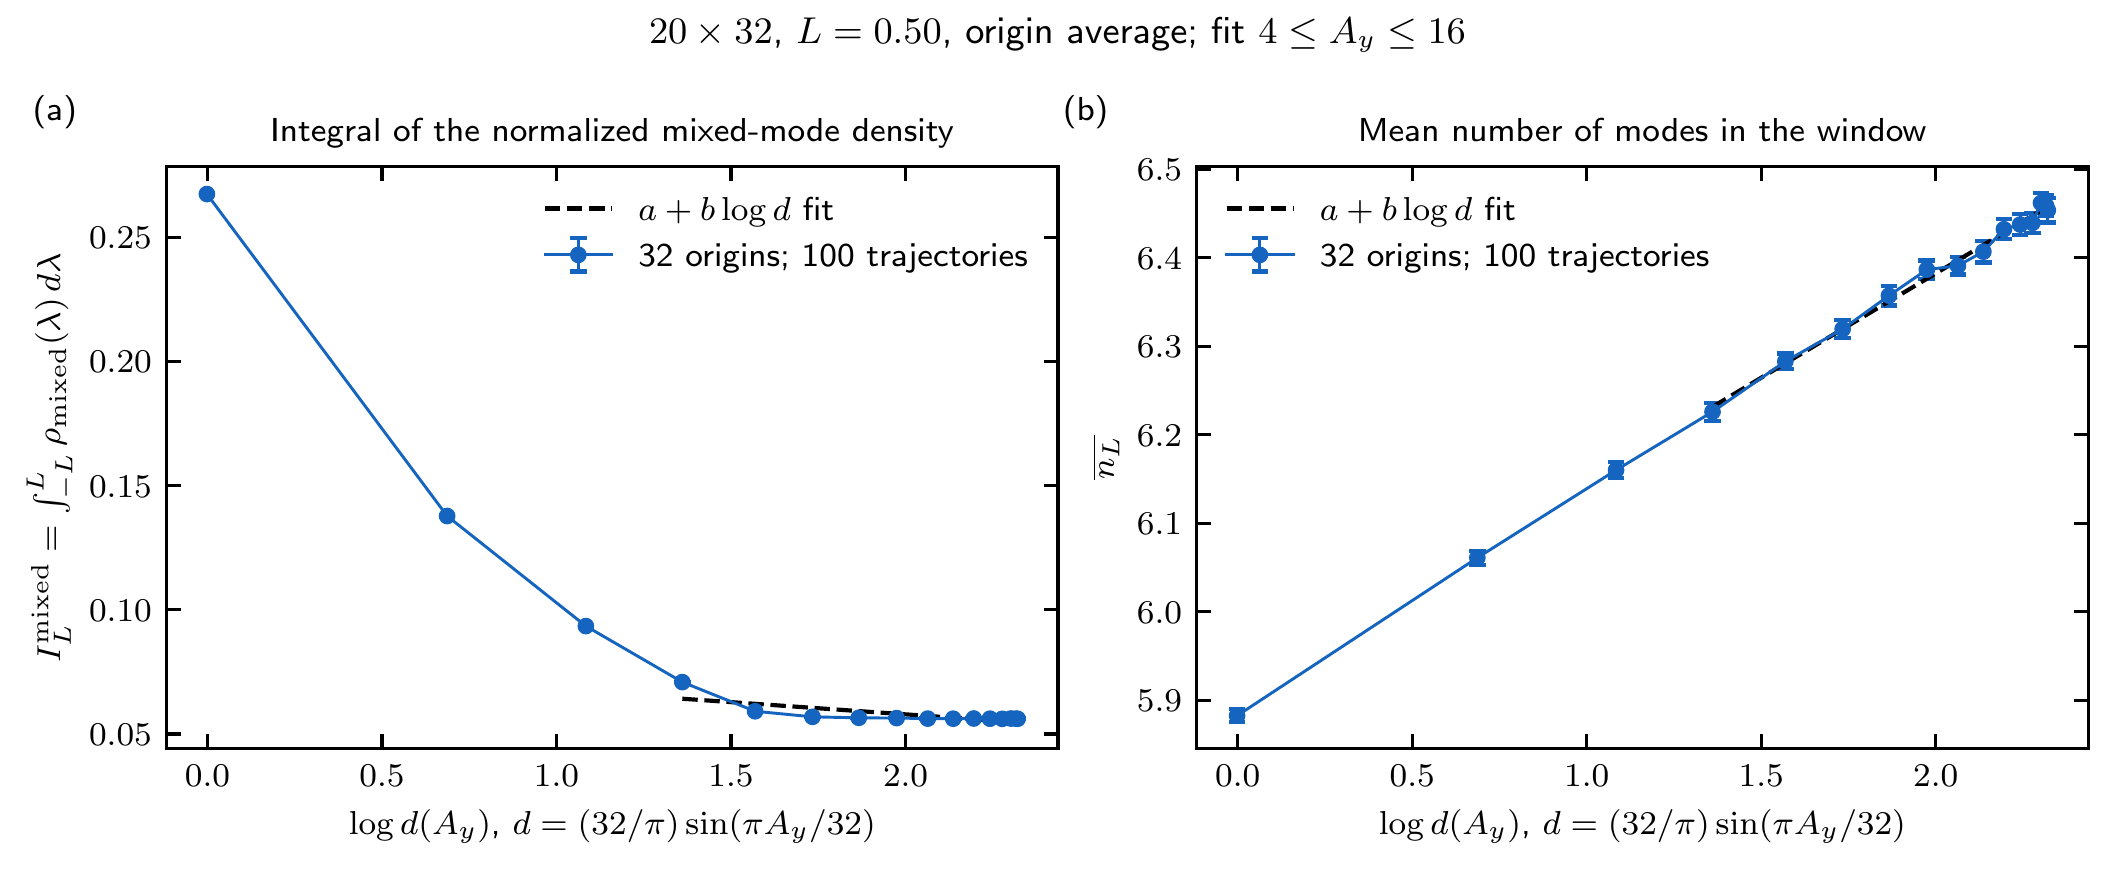

In [5]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.9))
for ax,key,title,ylabel,letter in zip(axes,
 ['mixed_normalized_integral','mode_count'],
 ['Integral of the normalized mixed-mode density','Mean number of modes in the window'],
 [r'$I_L^{\rm mixed}=\int_{-L}^{L}\rho_{\rm mixed}(\lambda)\,d\lambda$',r'$\overline{n_L}$'],['(a)','(b)']):
    ax.errorbar(summary.log_chord,summary[key],yerr=summary[key+'_sem'],color='#1565c0',marker='o',ls='-',lw=.7,ms=3,capsize=2,label='32 origins; 100 trajectories')
    fit=results['fits'][key][str(FIT_MIN_WIDTH)]
    grid=np.linspace(summary.loc[summary.Ay>=FIT_MIN_WIDTH,'log_chord'].min(),summary.log_chord.max(),200)
    ax.plot(grid,fit['intercept']+fit['slope']*grid,color='black',ls='--',lw=1,label=r'$a+b\log d$ fit')
    ax.set(xlabel=r'$\log d(A_y)$, $d=(32/\pi)\sin(\pi A_y/32)$',ylabel=ylabel,title=title)
    ax.text(-.15,1.08,letter,transform=ax.transAxes,fontweight='bold')
    ax.legend(frameon=False,fontsize=8,loc='best')
fig.suptitle(r'$20\times32$, $L=%.2f$, origin average; fit $%d\leq A_y\leq16$'%(L,FIT_MIN_WIDTH),fontsize=9)
export(fig,'spectral_window_vs_log_chord')

## Subsystem-width dependence
The left panel uses the exact normalization of the earlier mixed-mode plot. The right panel retains all modes in the density normalization, including those near the pure-state endpoints. Both use the same numerator.

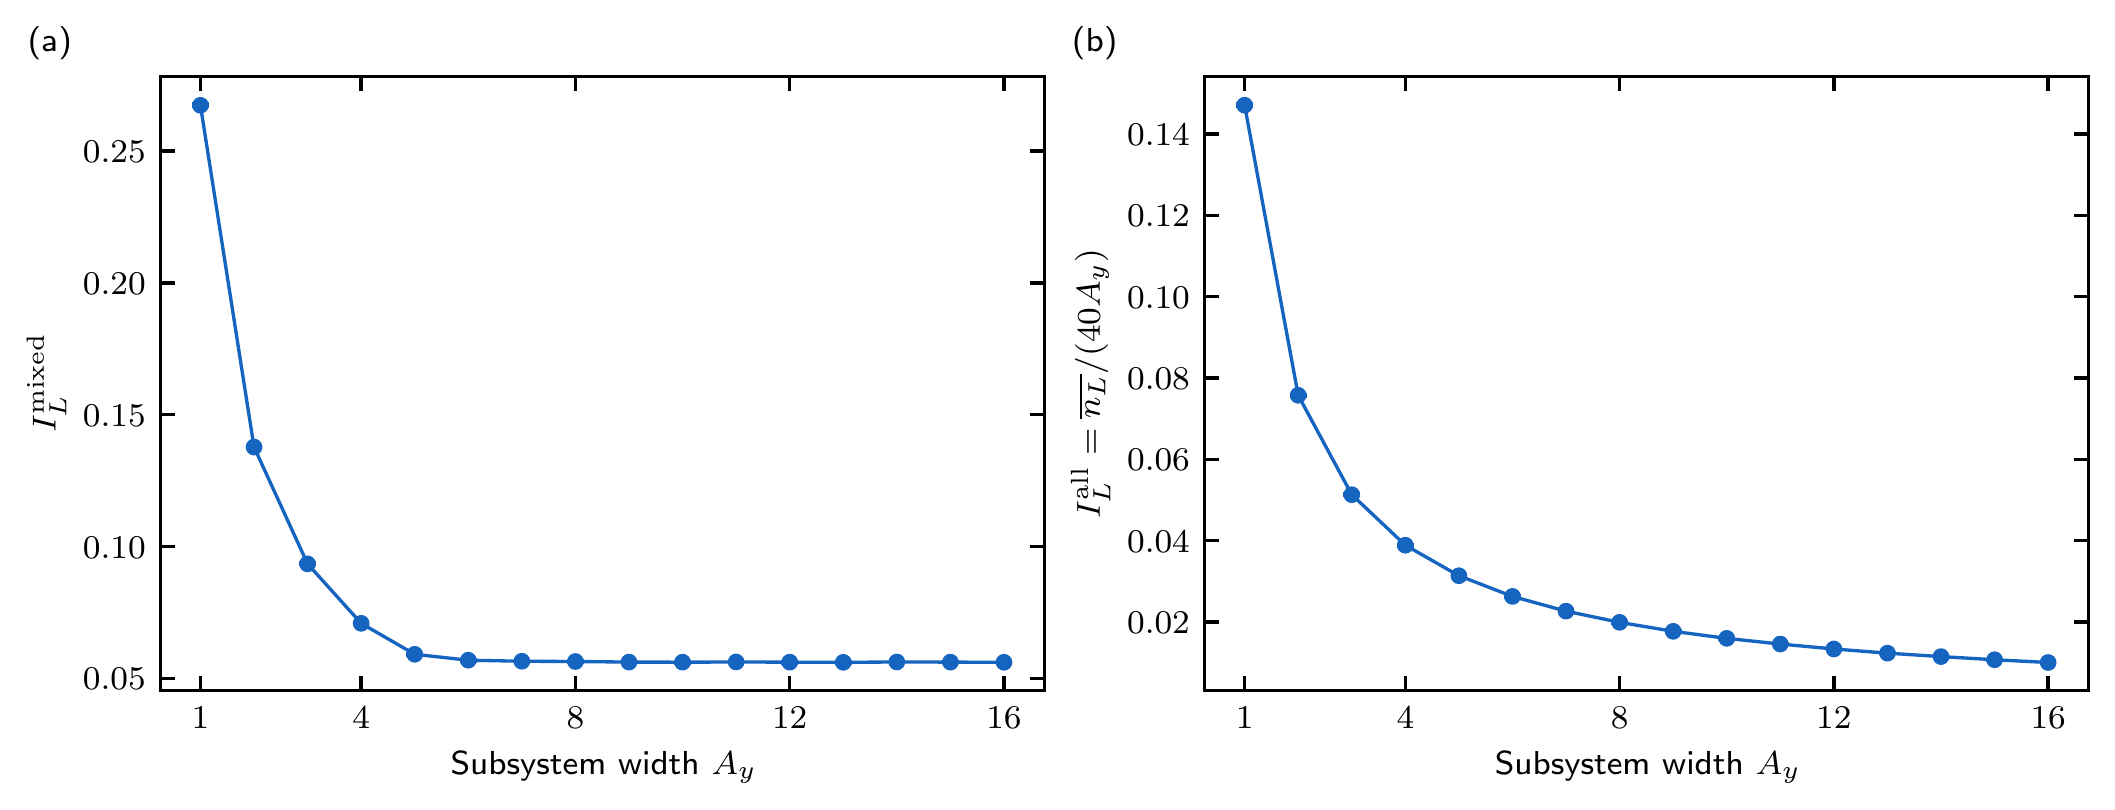

In [6]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.7))
for ax,key,ylabel,letter in zip(axes,['mixed_normalized_integral','all_modes_integral'],
 [r'$I_L^{\rm mixed}$',r'$I_L^{\rm all}=\overline{n_L}/(40A_y)$'],['(a)','(b)']):
    ax.errorbar(summary.Ay,summary[key],yerr=summary[key+'_sem'],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8)
    ax.set(xlabel=r'Subsystem width $A_y$',ylabel=ylabel,xticks=[1,4,8,12,16])
    ax.text(-.15,1.04,letter,transform=ax.transAxes,fontweight='bold')
export(fig,'spectral_window_vs_width')

Caption: 100 independent trajectories, initialized as pure states with a prepared exterior product frame; hard-wall production protocol at cycle 64. The full system is 20 by 32. Each subsystem includes every x and both orbitals, with width 1 through 16 and all 32 periodic origins. Spectra are computed per trajectory and origin. Counts are pooled over trajectories at each origin to normalize its mixed-mode density, then the 32 densities are averaged equally. Error bars are trajectory SEM (delta method for pooled ratios). Dashed fits use widths 4–16 by default and propagate correlations between widths. A narrow sharp spectral window can produce level-crossing features, so a straight-line fit alone does not establish an asymptotic scaling law.

## Numerical diagnostics
Raw spectra are preserved. Hermiticity is checked before numerical symmetrization. The origin-zero half-system spectrum is compared with the previously saved cache. Fixed-origin results are preserved in the separate earlier output directory. Statistical and fit outputs are saved separately so the window can be edited.

In [7]:
print(json.dumps({k:v for k,v in spectral_diagnostics.items() if k not in ('inputs','identity')},indent=2))
print(json.dumps(results,indent=2))
if (OUT/'cross_checks.json').exists():print((OUT/'cross_checks.json').read_text())
print('Completed: spectra NPZ, per-sample counts CSV, integrals CSV, covariance NPZ, diagnostics JSON, and two PDF/PNG figures.')

{
  "max_hermiticity_error": 0.0,
  "max_trace_error": 1.5010215292932116e-13,
  "max_frame_orthonormality_error": 1.102891900300992e-14,
  "raw_min": -1.000000000000013,
  "raw_max": 1.0000000000000417,
  "sample0_alternate_eigenvalue_error": 1.5432100042289676e-14,
  "half_system_previous_cache_max_error": 2.0539125955565396e-14,
  "previous_cache": {
    "path": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/half_system_centered_spectrum_n20_sizes_hard_alpha1_v1/centered_spectra_Ny032.npz",
    "sha256": "7af6e29738dca51b2dd93c64ea9473b38c9efad0ea1a996ac30f2c917e784fdf"
  },
  "cache_sha256": "8cd3aa2eee6df5a92d958f9df2025e530d9a3d62c9e33efb66c7fd129e71d260"
}
{
  "L": 0.5,
  "mixed_tolerance": 1e-08,
  "default_fit_min_width": 4,
  "fit_model": "intercept + slope * log[(32/pi) sin(pi Ay/32)]",
  "estimator": "at each origin normalize pooled trajectory counts; average the 32 nor